# Regression Models

## Goals

In this Assignmnet :

 - You Will impliment the regression models

## Tools
In this lab we will make use of: 
- NumPy, a popular library for scientific computing
- Matplotlib, a popular library for plotting data
- Pandas,  a Python library for data analysis

### Import Libraries

![Libraries](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Libraries.png?raw=true)


In [1]:
#Your code Here
#import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

###  Fetch Data From CSV Files

![Load Data](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Load%20N%20show.png?raw=true)

In [2]:
#Your code Here
#Read the trainig and testing data from the file
train_data = pd.read_csv('trainRegression.csv')
test_data = pd.read_csv('testRegression.csv')

### Show Data

In [3]:
#Your code Here
#Show the first 5 rows of the training data
print("Training Data:\n", train_data.head())
print("Testing Data:\n", test_data.head())


Training Data:
       X       R
0  0.01 -0.2730
1  0.02 -0.1170
2  0.03 -0.3090
3  0.04  0.0306
4  0.05 -0.0802
Testing Data:
      X      R
0  0.0 -0.226
1  0.1 -0.174
2  0.2  0.459
3  0.3  0.638
4  0.4  0.869


##### Expected Output


![Output 1](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/O1.png?raw=true)


### Type Casting of Data

![TypeCasting](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Type%20Casting.png?raw=true)


In [4]:
#Your code Here
#TypeCast the data into numpy array

x_train=np.array(train_data['X'])
r_train=np.array(train_data['R'])

x_test=np.array(test_data['X'])
r_test=np.array(test_data['R'])



### Plot Data

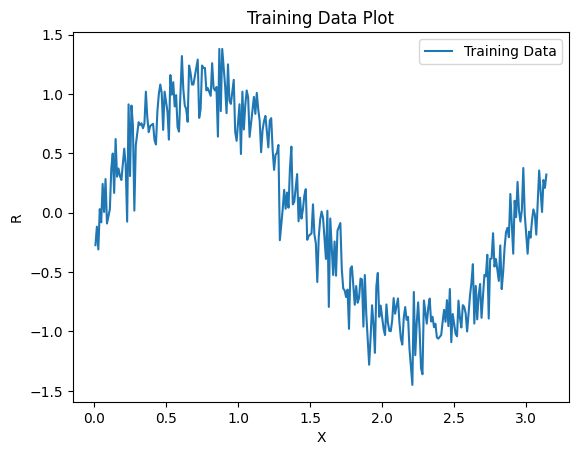

In [5]:
#Your code Here
#Plot your Training Data using matplotlib

plt.plot(x_train, r_train, label='Training Data')
plt.xlabel('X')
plt.ylabel('R')
plt.title('Training Data Plot')
plt.legend()
plt.show()


##### Expected Output


![Model Equations](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/O2.png?raw=true)


 ### Fit Linear Regression Model (Training data)

 As our linear Model was
 
![Cost Funtion](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Cost%20funtion1.png?raw=true
)

And using derivatives we transformed our model into 2 simultaneous equations

![Model Equations](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Linear%20Model%20Eqs.png?raw=true)


Then converted it in matrix form

![Model Equations](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Linear%20Model.png?raw=true)



NOTE :  Now you are required to compute values wihtout using foor loop on tarining data
- HINT : Use numpy library for this purpose 

In [6]:
#Your code Here
#For loop is not recommended in these cases, 
#use numpy functions to calculate the values of above variables in one line of code.
#Such as x.shape for number of rows, sum() for sum of all elements in x
#np.dot() or multiply suntion for square of x 

matrix_A = np.array([[x_train.shape[0], np.sum(x_train)], [np.sum(x_train), np.dot(x_train, x_train)]])
print("Matrix A:\n", matrix_A)

matrix_B = np.array([[np.sum(r_train)], [np.dot(x_train, r_train)]])
print("Matrix B:\n", matrix_B)



Matrix A:
 [[283.     444.95  ]
 [444.95   932.7465]]
Matrix B:
 [[   1.39087  ]
 [-126.6414295]]


Expected output

![Linear Model MAtrixes](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Matrixs%20Linear.png?raw=true)


#### Compute Valus of Both Θ`s


In [7]:
#Your code Here
#Calculate the values of 0_node and 0_1 using Matrix Multiplication
#Hint: Use X = A^-1 * B to calculate the values of 0_node and 0_1

matrix_X = np.linalg.inv(matrix_A)
matrix_X = np.dot(matrix_X, matrix_B)
print("Matrix X:\n", matrix_X)



Matrix X:
 [[ 0.8736061 ]
 [-0.55251074]]


Expected Output

![Linear Model MAtrixes](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Matrixs%20LinearT.png?raw=true)


### Run Predictions (Testing data)

In [8]:
# Your code Here
# In order to calculate the pridicted values of y
# Use the formula y = 0_node + 0_1 * x
# _____DO NOT USE FOR LOOP_____
# instead Convert the column of test_x into numpy a 2 dimensional matrix
# then use matrix multiplication to calculate the predicted values of y

y_predicted = matrix_X[0] + matrix_X[1] * x_test

print("Predicted values of y:\n", y_predicted)

Predicted values of y:
 [ 0.8736061   0.81835502  0.76310395  0.70785287  0.6526018   0.59735072
  0.54209965  0.48684858  0.4315975   0.37634643  0.32109535  0.26584428
  0.2105932   0.15534213  0.10009106  0.04483998 -0.01041109 -0.06566217
 -0.12091324 -0.17616432 -0.23141539 -0.28666646 -0.34191754 -0.39716861
 -0.45241969 -0.50767076 -0.56292184 -0.61817291 -0.67342398 -0.72867506
 -0.78392613 -0.83917721]


### Mean Square Error

![Cost Funtion](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Cost%20funtion1.png?raw=true
)

In [9]:
#Your code Here
#Using cost function calculate the cost of the model
cost = np.mean((y_predicted - r_test) ** 2)
print("Cost of the model:\n", cost)


Cost of the model:
 0.3159321720459774


Expected Output

![MSE of Linear](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/MSE%20Linear.png?raw=true
)

### Plot Data (Train and Test Data)

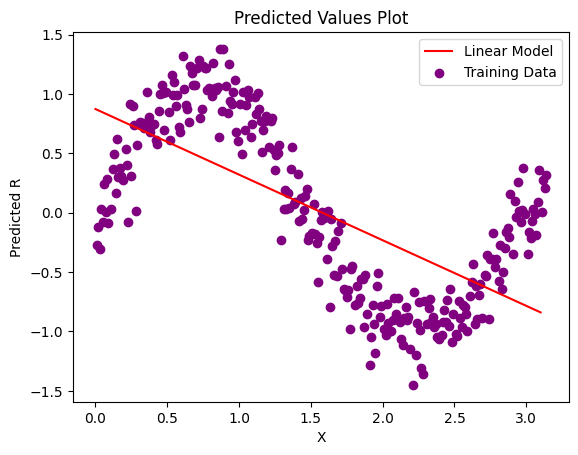

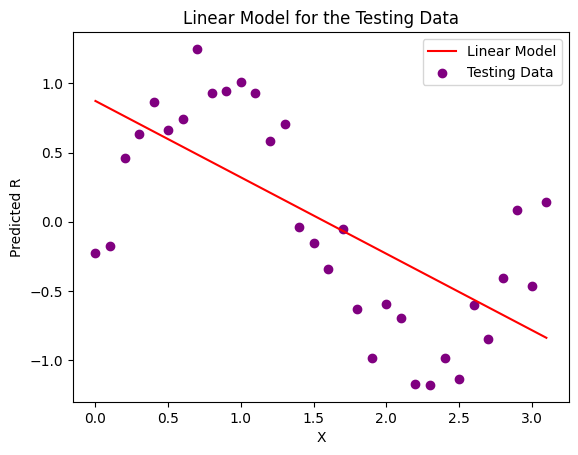

In [10]:
##Your code Here
#Plot the predicted values of y against the test_x

plt.plot(x_test, y_predicted, label='Linear Model',c='red')
plt.scatter(x_train, r_train, label='Training Data',c='purple')
plt.xlabel('X')
plt.ylabel('Predicted R')
plt.title('Predicted Values Plot')
plt.legend()
plt.show()


plt.plot(x_test, y_predicted, label='Linear Model',c='red')
plt.scatter(x_test, r_test, label='Testing Data',c='purple')
plt.xlabel('X')
plt.ylabel('Predicted R')
plt.title('Linear Model for the Testing Data')
plt.legend()
plt.show()


### Expected Outputs for Linear Model

![Training Data Plot](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Linear%20O.png?raw=true)

![Test Data Plot](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Linear%20O%20test.png?raw=true)


## Now Fit The Quadratic Model

 As our Quadratic Model was
 
![Cost Funtion for quadratic ](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Cost%20funtion2.png?raw=true
)

And using derivatives we transformed our model into 3 simultaneous equations

![Model Equations of quadratic](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Quad%20Model%20Eqs.png?raw=true)


Then converted it in matrix form

![Model Formula of Quadratic](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Quad%20Model1.png?raw=true)



NOTE :  Now you are required to compute values wihtout using foor loop on tarining data
- HINT : Use numpy library for this purpose 

In [11]:
#Your code Here
#For loop is not recommended in these cases, 
#use numpy functions to calculate the values of above variables in one line of code.
#Such as x.shape for number of rows, sum() for sum of all elements in x
#np.dot() or multiply suntion for square of x 

Matrix_A = np.array([
    [x_train.shape[0], np.sum(x_train),     np.sum(x_train**2)],
    [np.sum(x_train),  np.sum(x_train**2),   np.sum(x_train**3)],
    [np.sum(x_train**2), np.sum(x_train**3), np.sum(x_train**4)]
])

print("Matrix A:\n", Matrix_A)

matrix_B = np.array([
    [np.sum(r_train)],
    [np.dot(x_train, r_train)],
    [np.dot(x_train**2, r_train)]
])
print("Matrix B:\n", matrix_B)





Matrix A:
 [[ 283.          444.95        932.7465    ]
 [ 444.95        932.7465     2199.781025  ]
 [ 932.7465     2199.781025   5533.85257677]]
Matrix B:
 [[   1.39087   ]
 [-126.6414295 ]
 [-378.87568955]]


Expected Output

![Quadratic Model Matrixes](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Matrixs%20Quad1.png?raw=true)

#### Compute Valus Of Three Θ`s


In [12]:
#Your code Here
#Calculate the values of 0_node and 0_1 using Matrix Multiplication
#Hint: Use X = A^-1 * B to calculate the values of 0_node , 0_1 and 0_2

matrix_X = np.linalg.inv(Matrix_A)
matrix_X = np.dot(matrix_X, matrix_B)
print("Matrix X:\n", matrix_X)



Matrix X:
 [[ 1.10611454]
 [-0.99606599]
 [ 0.14104585]]


Expected Output

![Quadratic Model MAtrixes](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Matrixs%20Quad.png?raw=true)


### Run Predictions (Testing data)

In [13]:
# Your code Here
# In order to calculate the pridicted values of y
# Use the formula y = 0_node + 0_1 * x
# _____DO NOT USE FOR LOOP_____
# instead Convert the column of test_x into numpy a 2 dimensional matrix
# then use matrix multiplication to calculate the predicted values of y

y_predicted = matrix_X[0] + matrix_X[1] * x_test + matrix_X[2] * x_test**2

print("Predicted values of y:\n", y_predicted)


Predicted values of y:
 [ 1.10611454  1.0079184   0.91254317  0.81998887  0.73025548  0.643343
  0.55925145  0.47798081  0.39953109  0.32390228  0.25109439  0.18110742
  0.11394137  0.04959623 -0.01192799 -0.0706313  -0.12651368 -0.17957515
 -0.22981571 -0.27723534 -0.32183406 -0.36361187 -0.40256875 -0.43870472
 -0.47201977 -0.50251391 -0.53018713 -0.55503943 -0.57707081 -0.59628128
 -0.61267083 -0.62623946]


### Mean Square Error

![Cost Funtion](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Cost%20funtion2.png?raw=true
)

In [14]:
#Your code Here
#Using cost function calculate the cost of the model

cost = np.mean((y_predicted - r_test) ** 2)
print("Cost of the model:\n", cost)


Cost of the model:
 0.32604179594962834


Expected Output

![MSE of Quadratic](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/MSE%20Quad.png?raw=true
)

### Plot Data (Train and Test Data)

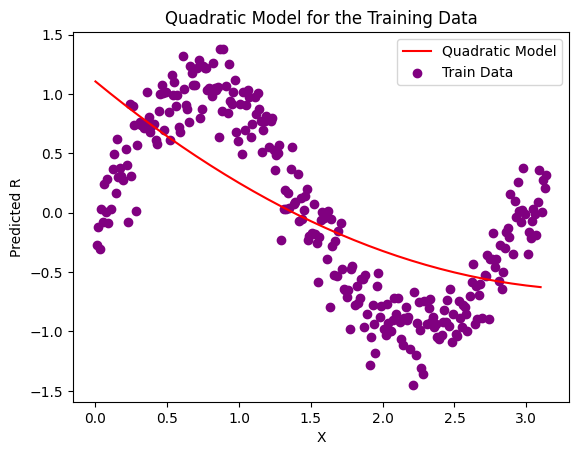

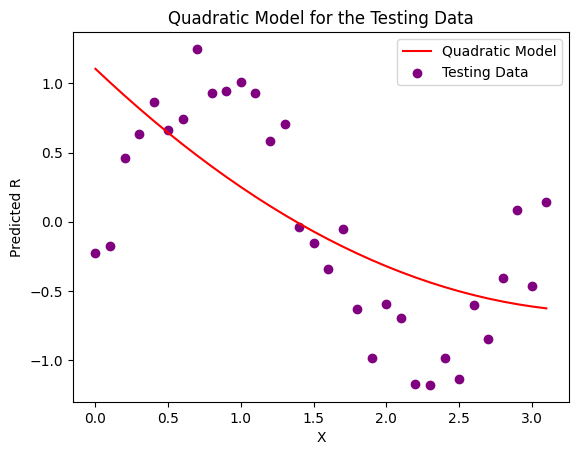

In [15]:
##Your code Here
#Plot the predicted values of y against the test_x

plt.plot(x_test, y_predicted, label='Quadratic Model',c='red')
plt.scatter(x_train, r_train, label='Train Data',c='purple')
plt.xlabel('X')
plt.ylabel('Predicted R')
plt.title('Quadratic Model for the Training Data')
plt.legend()
plt.show()

plt.plot(x_test, y_predicted, label='Quadratic Model',c='red')
plt.scatter(x_test, r_test, label='Testing Data',c='purple')
plt.xlabel('X')
plt.ylabel('Predicted R')
plt.title('Quadratic Model for the Testing Data')
plt.legend()
plt.show()

### Expected Outputs for Quadratic Model

![Training Data Plot](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Quad%20O.png?raw=true)

![Test Data Plot](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Quad%20O%20tets.png?raw=true)


## Now Fit The Cubic Model

Cubic Model in matrix form

![Model Formula of Quadratic](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Cubic%20Model.png?raw=true)



NOTE :  Now you are required to compute values wihtout using foor loop on tarining data
- HINT : Use numpy library for this purpose 

In [16]:
#Your code Here
#For loop is not recommended in these cases, 
#use numpy functions to calculate the values of above variables in one line of code.
#Such as x.shape for number of rows, sum() for sum of all elements in x
#np.dot() or multiply suntion for square of x 

matrix_A = np.array([
    [x_train.shape[0], np.sum(x_train),     np.sum(x_train**2), np.sum(x_train**3)],
    [np.sum(x_train),  np.sum(x_train**2),   np.sum(x_train**3), np.sum(x_train**4)],
    [np.sum(x_train**2), np.sum(x_train**3), np.sum(x_train**4), np.sum(x_train**5)],
    [np.sum(x_train**3), np.sum(x_train**4), np.sum(x_train**5), np.sum(x_train**6)]
])
print("Matrix A:\n", matrix_A)

matrix_B = np.array([
    [np.sum(r_train)],
    [np.dot(x_train, r_train)],
    [np.dot(x_train**2, r_train)],
    [np.dot(x_train**3, r_train)]
])
print("Matrix B:\n", matrix_B)




Matrix A:
 [[  283.           444.95         932.7465      2199.781025  ]
 [  444.95         932.7465      2199.781025    5533.85257677]
 [  932.7465      2199.781025    5533.85257677 14501.33829628]
 [ 2199.781025    5533.85257677 14501.33829628 39086.48841058]]
Matrix B:
 [[   1.39087   ]
 [-126.6414295 ]
 [-378.87568955]
 [-952.32410353]]


Expected Output

![Cubic Model Matrixes](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Matrixs%20Cubic1.png?raw=true)

#### Compute Valus Of Four Θ`s


In [17]:
#Your code Here
#Calculate the values of 0_node and 0_1 using Matrix Multiplication
#Hint: Use X = A^-1 * B to calculate the values of 0_node , 0_1 ,0_2 and 0_3

matrix_X = np.linalg.inv(matrix_A)
matrix_X = np.dot(matrix_X, matrix_B)
print("Matrix X:\n", matrix_X)


Matrix X:
 [[-0.18862637]
 [ 3.94071895]
 [-3.78251095]
 [ 0.83166145]]


Expected Output

![Cubic Model MAtrixes](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Matrixs%20Cubic.png?raw=true)


### Run Predictions (Testing data)

In [18]:
# Your code Here
# In order to calculate the pridicted values of y
# Use the formula y = 0_node + 0_1 * x
# _____DO NOT USE FOR LOOP_____
# instead Convert the column of test_x into numpy a 2 dimensional matrix
# then use matrix multiplication to calculate the predicted values of y

y_predicted = matrix_X[0] + matrix_X[1] * x_test + matrix_X[2] * x_test**2 + matrix_X[3] * x_test**3



### Mean Square Error

In [19]:
#Your code Here
#Using cost function calculate the cost of the model
cost = np.mean((y_predicted - r_test) ** 2)
print("Cost of the model:\n", cost)

Cost of the model:
 0.051542057690952714


Expected Output

![MSE of Cubic](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/MSE%20Cubic.png?raw=true
)

### Plot Data (Train and Test Data)

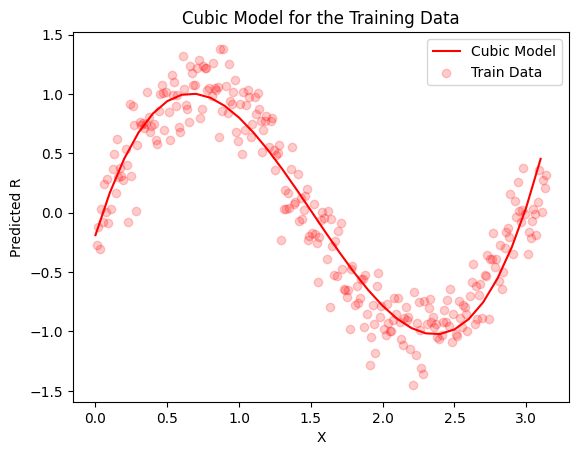

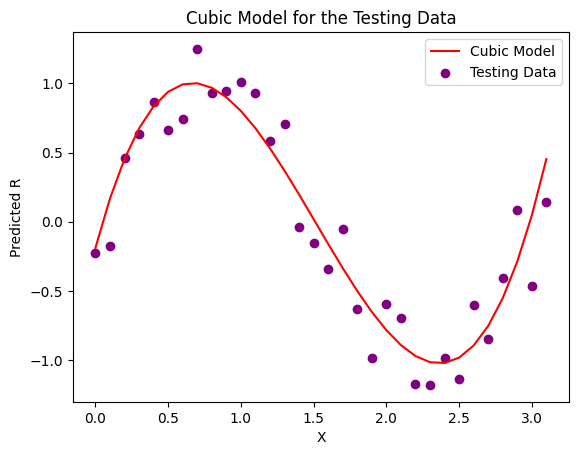

In [20]:
##Your code Here
#Plot the predicted values of y against the test_x

plt.plot(x_test, y_predicted, label='Cubic Model',c='red')
plt.scatter(x_train, r_train, label='Train Data',c='red',alpha=0.2)
plt.xlabel('X')
plt.ylabel('Predicted R')
plt.title('Cubic Model for the Training Data')
plt.legend()
plt.show()

plt.plot(x_test, y_predicted, label='Cubic Model',c='red')
plt.scatter(x_test, r_test, label='Testing Data',c='purple')
plt.xlabel('X')
plt.ylabel('Predicted R')
plt.title('Cubic Model for the Testing Data')
plt.legend()
plt.show()


### Expected Outputs for Cubic Model

![Training Data Plot](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Cubic%20O.png?raw=true)

![Test Data Plot](https://github.com/ahmad-14a/CS-F20-ML/blob/main/Regression-Assignment%202/Cubic%20O%20test.png?raw=true)


### Now You Are Required To Fit Your 4 , 5 and 6 degree Models Step By Step As You Did Before

## Now Fit The 4 degree Model

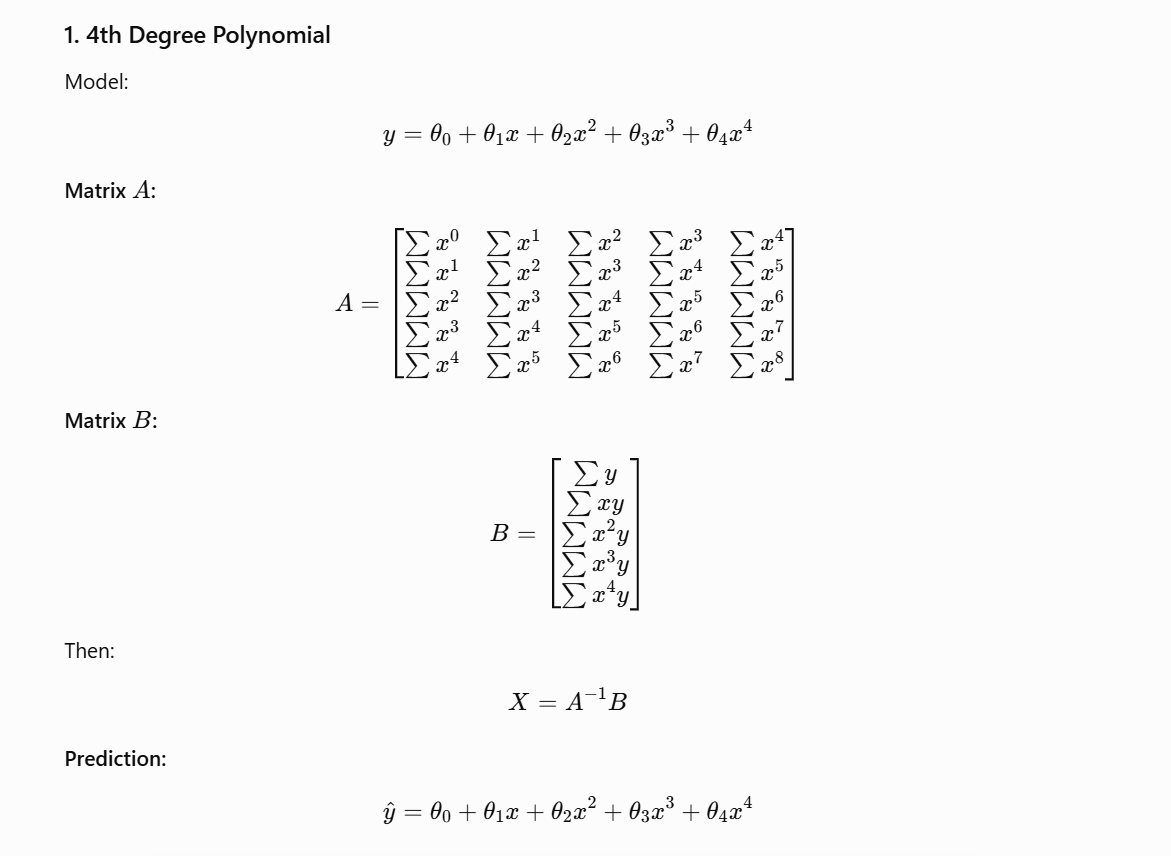

Matrix A:
 [[2.83000000e+02 4.44950000e+02 9.32746500e+02 2.19978103e+03
  5.53385258e+03]
 [4.44950000e+02 9.32746500e+02 2.19978103e+03 5.53385258e+03
  1.45013383e+04]
 [9.32746500e+02 2.19978103e+03 5.53385258e+03 1.45013383e+04
  3.90864884e+04]
 [2.19978103e+03 5.53385258e+03 1.45013383e+04 3.90864884e+04
  1.07548336e+05]
 [5.53385258e+03 1.45013383e+04 3.90864884e+04 1.07548336e+05
  3.00624107e+05]]
Matrix B:
 [[ 1.39087000e+00]
 [-1.26641430e+02]
 [-3.78875690e+02]
 [-9.52324104e+02]
 [-2.30897053e+03]]
Matrix X:
 [[-0.40789474]
 [ 5.3320982 ]
 [-5.77179206]
 [ 1.81519401]
 [-0.15632916]]
Predicted values of y:
 [-0.40789474  0.06939672  0.44192464  0.7200174   0.9136282   1.03233502
  1.08534068  1.0814728   1.02918381  0.93655094  0.81127625  0.66068659
  0.49173364  0.31099387  0.12466857 -0.06141615 -0.2418094  -0.41143544
 -0.56559375 -0.69995899 -0.81058102 -0.89388486 -0.94667076 -0.96611413
 -0.94976558 -0.89555091 -0.80177112 -0.66710238 -0.49059607 -0.27167873
 -0.0

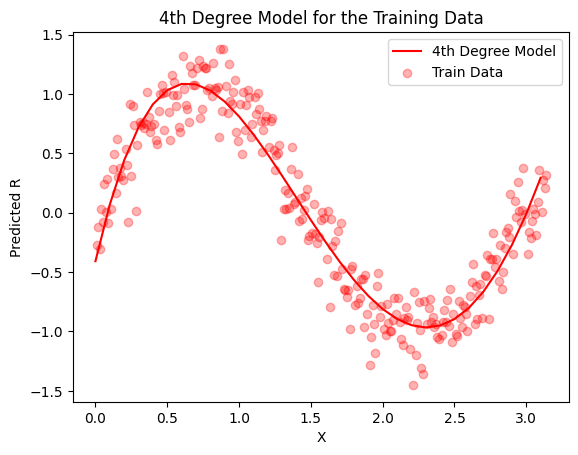

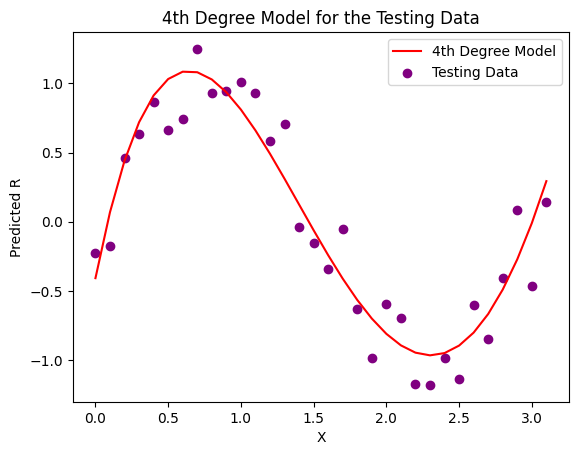

In [21]:
#Your code Here

Matrix_A = np.array([
    [np.sum(x_train**0), np.sum(x_train**1), np.sum(x_train**2), np.sum(x_train**3), np.sum(x_train**4)],
    [np.sum(x_train**1), np.sum(x_train**2), np.sum(x_train**3), np.sum(x_train**4), np.sum(x_train**5)],
    [np.sum(x_train**2), np.sum(x_train**3), np.sum(x_train**4), np.sum(x_train**5), np.sum(x_train**6)],
    [np.sum(x_train**3), np.sum(x_train**4), np.sum(x_train**5), np.sum(x_train**6), np.sum(x_train**7)],
    [np.sum(x_train**4), np.sum(x_train**5), np.sum(x_train**6), np.sum(x_train**7), np.sum(x_train**8)]
])
print("Matrix A:\n", Matrix_A)

Matrix_B = np.array([
    [np.sum(r_train)],
    [np.sum(x_train * r_train)],
    [np.sum(x_train**2 * r_train)],
    [np.sum(x_train**3 * r_train)],
    [np.sum(x_train**4 * r_train)]
])
print("Matrix B:\n", Matrix_B)

Matrix_X = np.linalg.solve(Matrix_A, Matrix_B)
print("Matrix X:\n", Matrix_X)

y_predicted = (
    Matrix_X[0]
    + Matrix_X[1] * x_test
    + Matrix_X[2] * x_test**2
    + Matrix_X[3] * x_test**3
    + Matrix_X[4] * x_test**4
)
print("Predicted values of y:\n", y_predicted)

cost = np.mean((y_predicted - r_test) ** 2) 
print("Cost of the model:\n", cost)

plt.plot(x_test, y_predicted, label='4th Degree Model', c='red')
plt.scatter(x_train, r_train, label='Train Data', c='red',alpha=0.3)
plt.xlabel('X')
plt.ylabel('Predicted R')
plt.title('4th Degree Model for the Training Data')
plt.legend()
plt.show()


plt.plot(x_test, y_predicted, label='4th Degree Model', c='red')
plt.scatter(x_test, r_test, label='Testing Data', c='purple')
plt.xlabel('X')
plt.ylabel('Predicted R')
plt.title('4th Degree Model for the Testing Data')
plt.legend()
plt.show()


## Now Fit The 5 degree Model
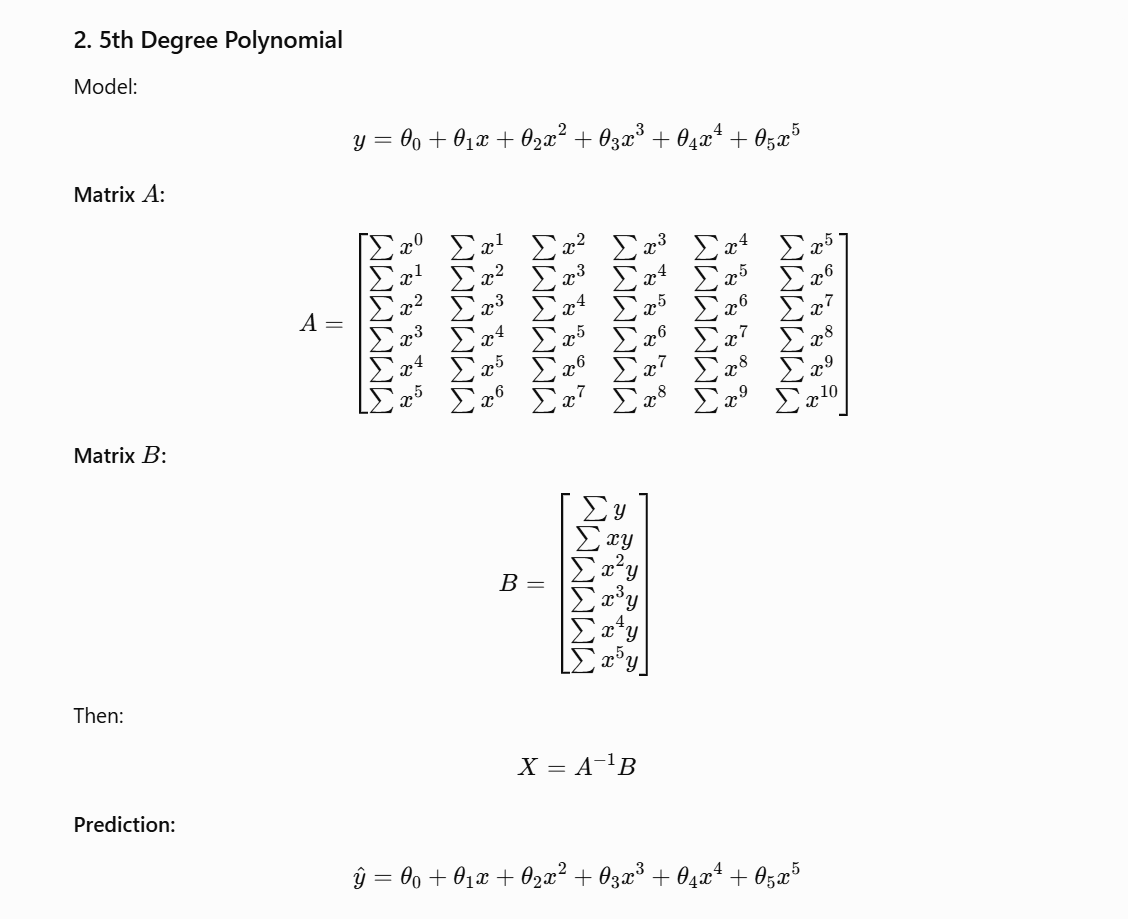

Matrix A:
 [[2.83000000e+02 4.44950000e+02 9.32746500e+02 2.19978103e+03
  5.53385258e+03 1.45013383e+04]
 [4.44950000e+02 9.32746500e+02 2.19978103e+03 5.53385258e+03
  1.45013383e+04 3.90864884e+04]
 [9.32746500e+02 2.19978103e+03 5.53385258e+03 1.45013383e+04
  3.90864884e+04 1.07548336e+05]
 [2.19978103e+03 5.53385258e+03 1.45013383e+04 3.90864884e+04
  1.07548336e+05 3.00624107e+05]
 [5.53385258e+03 1.45013383e+04 3.90864884e+04 1.07548336e+05
  3.00624107e+05 8.50829605e+05]
 [1.45013383e+04 3.90864884e+04 1.07548336e+05 3.00624107e+05
  8.50829605e+05 2.43237118e+06]]
Matrix B:
 [[ 1.39087000e+00]
 [-1.26641430e+02]
 [-3.78875690e+02]
 [-9.52324104e+02]
 [-2.30897053e+03]
 [-5.57500637e+03]]
Matrix X:
 [[-0.15135453]
 [ 2.89713972]
 [-0.36242335]
 [-2.76674175]
 [ 1.48161173]
 [-0.20822932]]
Predicted values of y:
 [-0.15135453  0.13211454  0.39374649  0.62196231  0.80823914  0.94686034
  1.03466564  1.07080128  1.0564701   0.99468168  0.89000249  0.74830595
  0.57652264  0.3823

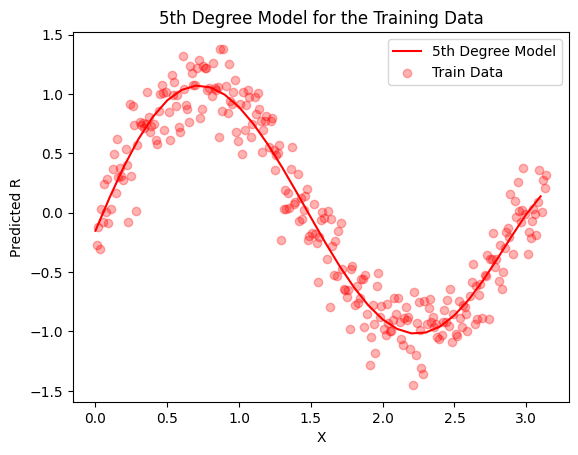

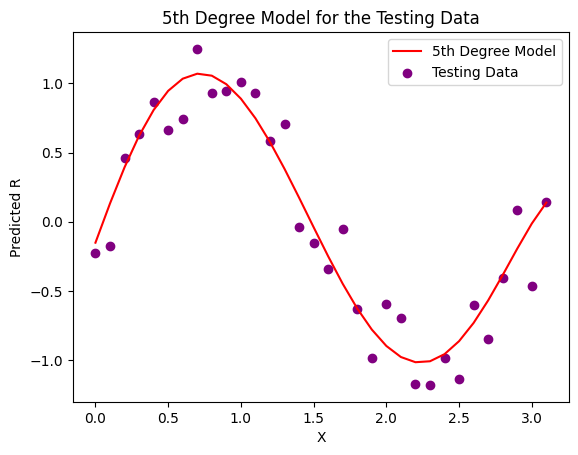

In [22]:
#Your code Here

Matrix_A = np.array([
    [np.sum(x_train**0), np.sum(x_train**1), np.sum(x_train**2), np.sum(x_train**3), np.sum(x_train**4), np.sum(x_train**5)],
    [np.sum(x_train**1), np.sum(x_train**2), np.sum(x_train**3), np.sum(x_train**4), np.sum(x_train**5), np.sum(x_train**6)],
    [np.sum(x_train**2), np.sum(x_train**3), np.sum(x_train**4), np.sum(x_train**5), np.sum(x_train**6), np.sum(x_train**7)],
    [np.sum(x_train**3), np.sum(x_train**4), np.sum(x_train**5), np.sum(x_train**6), np.sum(x_train**7), np.sum(x_train**8)],
    [np.sum(x_train**4), np.sum(x_train**5), np.sum(x_train**6), np.sum(x_train**7), np.sum(x_train**8), np.sum(x_train**9)],
    [np.sum(x_train**5), np.sum(x_train**6), np.sum(x_train**7), np.sum(x_train**8), np.sum(x_train**9), np.sum(x_train**10)]
])
print("Matrix A:\n", Matrix_A)

Matrix_B = np.array([
    [np.sum(r_train)],
    [np.sum(x_train * r_train)],
    [np.sum(x_train**2 * r_train)],
    [np.sum(x_train**3 * r_train)],
    [np.sum(x_train**4 * r_train)],
    [np.sum(x_train**5 * r_train)]
])
print("Matrix B:\n", Matrix_B)

Matrix_X = np.linalg.solve(Matrix_A, Matrix_B)
print("Matrix X:\n", Matrix_X)

y_predicted = (
    Matrix_X[0]
    + Matrix_X[1] * x_test
    + Matrix_X[2] * x_test**2
    + Matrix_X[3] * x_test**3
    + Matrix_X[4] * x_test**4
    + Matrix_X[5] * x_test**5
)
print("Predicted values of y:\n", y_predicted)

cost = np.mean((y_predicted - r_test) ** 2) 
print("Cost of the model:\n", cost)

plt.plot(x_test, y_predicted, label='5th Degree Model', c='red')
plt.scatter(x_train, r_train, label='Train Data', c='red',alpha=0.3)
plt.xlabel('X')
plt.ylabel('Predicted R')
plt.title('5th Degree Model for the Training Data')
plt.legend()
plt.show()


plt.plot(x_test, y_predicted, label='5th Degree Model', c='red')
plt.scatter(x_test, r_test, label='Testing Data', c='purple')
plt.xlabel('X')
plt.ylabel('Predicted R')
plt.title('5th Degree Model for the Testing Data')
plt.legend()
plt.show()


## Now Fit The 6 degree Model

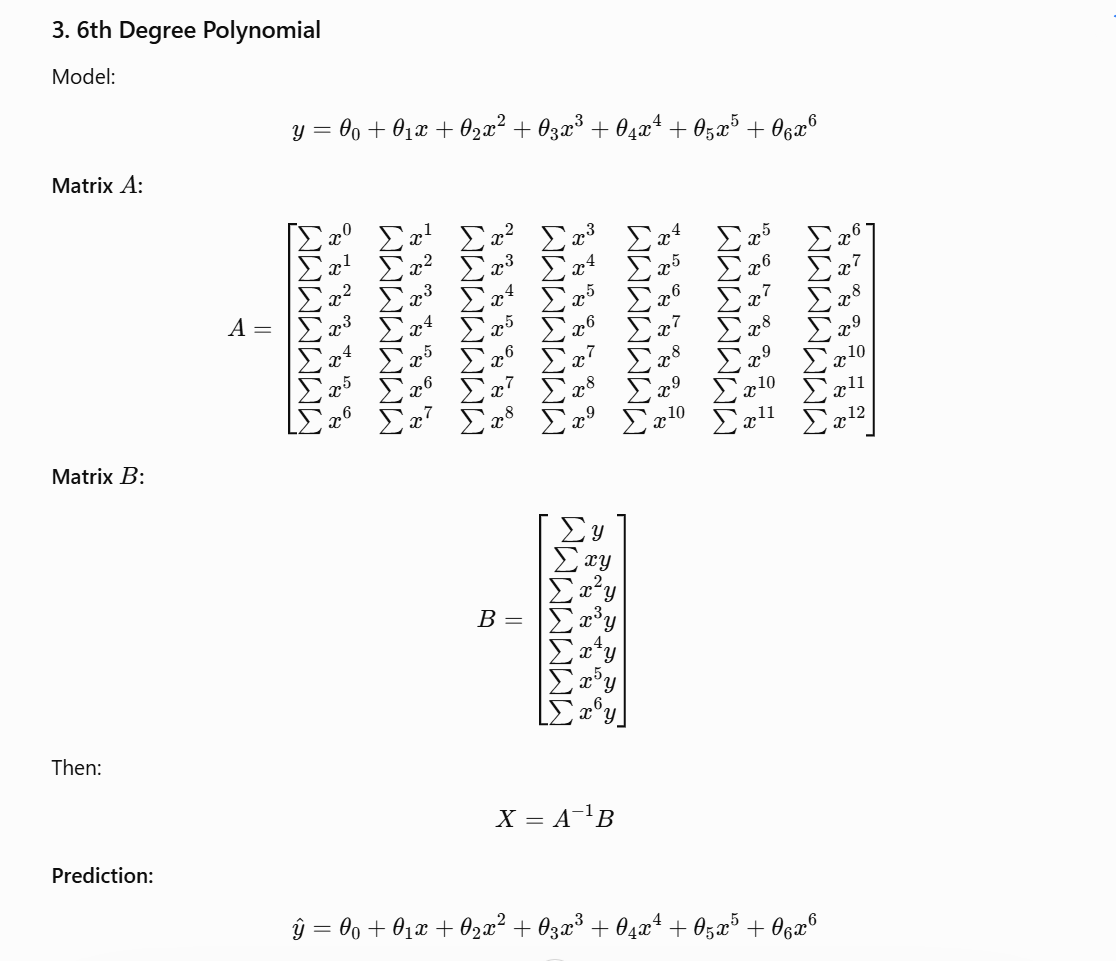

Matrix A:
 [[2.83000000e+02 4.44950000e+02 9.32746500e+02 2.19978103e+03
  5.53385258e+03 1.45013383e+04 3.90864884e+04]
 [4.44950000e+02 9.32746500e+02 2.19978103e+03 5.53385258e+03
  1.45013383e+04 3.90864884e+04 1.07548336e+05]
 [9.32746500e+02 2.19978103e+03 5.53385258e+03 1.45013383e+04
  3.90864884e+04 1.07548336e+05 3.00624107e+05]
 [2.19978103e+03 5.53385258e+03 1.45013383e+04 3.90864884e+04
  1.07548336e+05 3.00624107e+05 8.50829605e+05]
 [5.53385258e+03 1.45013383e+04 3.90864884e+04 1.07548336e+05
  3.00624107e+05 8.50829605e+05 2.43237118e+06]
 [1.45013383e+04 3.90864884e+04 1.07548336e+05 3.00624107e+05
  8.50829605e+05 2.43237118e+06 7.01172536e+06]
 [3.90864884e+04 1.07548336e+05 3.00624107e+05 8.50829605e+05
  2.43237118e+06 7.01172536e+06 2.03540142e+07]]
Matrix B:
 [[ 1.39087000e+00]
 [-1.26641430e+02]
 [-3.78875690e+02]
 [-9.52324104e+02]
 [-2.30897053e+03]
 [-5.57500637e+03]
 [-1.35290159e+04]]
Matrix X:
 [[-0.12883598]
 [ 2.59932802]
 [ 0.58098511]
 [-3.96416677]
 [

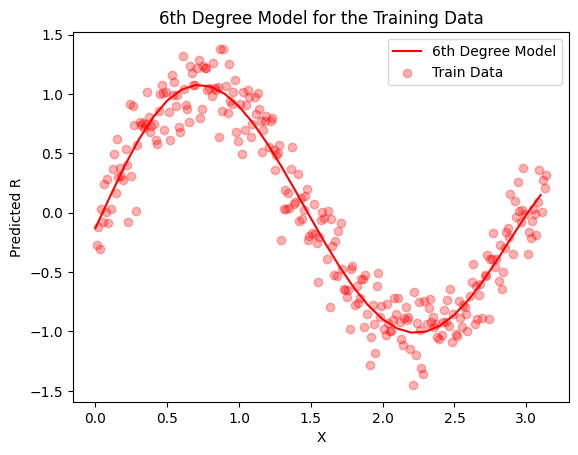

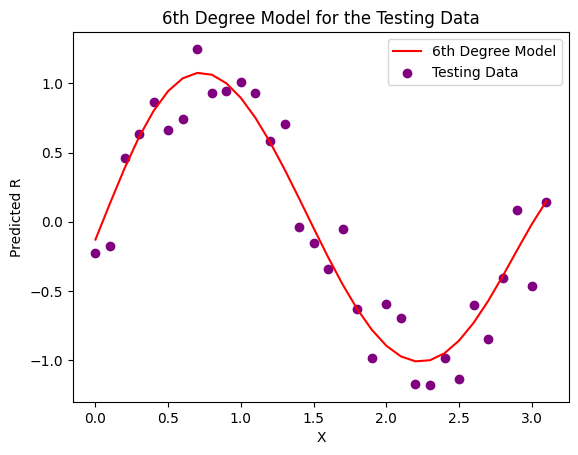

In [23]:
#Your code Here
Matrix_A = np.array([
    [np.sum(x_train**0), np.sum(x_train**1), np.sum(x_train**2), np.sum(x_train**3), np.sum(x_train**4), np.sum(x_train**5), np.sum(x_train**6)],
    [np.sum(x_train**1), np.sum(x_train**2), np.sum(x_train**3), np.sum(x_train**4), np.sum(x_train**5), np.sum(x_train**6), np.sum(x_train**7)],
    [np.sum(x_train**2), np.sum(x_train**3), np.sum(x_train**4), np.sum(x_train**5), np.sum(x_train**6), np.sum(x_train**7), np.sum(x_train**8)],
    [np.sum(x_train**3), np.sum(x_train**4), np.sum(x_train**5), np.sum(x_train**6), np.sum(x_train**7), np.sum(x_train**8), np.sum(x_train**9)],
    [np.sum(x_train**4), np.sum(x_train**5), np.sum(x_train**6), np.sum(x_train**7), np.sum(x_train**8), np.sum(x_train**9), np.sum(x_train**10)],
    [np.sum(x_train**5), np.sum(x_train**6), np.sum(x_train**7), np.sum(x_train**8), np.sum(x_train**9), np.sum(x_train**10), np.sum(x_train**11)],
    [np.sum(x_train**6), np.sum(x_train**7), np.sum(x_train**8), np.sum(x_train**9), np.sum(x_train**10), np.sum(x_train**11), np.sum(x_train**12)]
])
print("Matrix A:\n", Matrix_A)

Matrix_B = np.array([
    [np.sum(r_train)],
    [np.sum(x_train * r_train)],
    [np.sum(x_train**2 * r_train)],
    [np.sum(x_train**3 * r_train)],
    [np.sum(x_train**4 * r_train)],
    [np.sum(x_train**5 * r_train)],
    [np.sum(x_train**6 * r_train)]
])
print("Matrix B:\n", Matrix_B)

Matrix_X = np.linalg.solve(Matrix_A, Matrix_B)
print("Matrix X:\n", Matrix_X)

y_predicted = (
    Matrix_X[0]
    + Matrix_X[1] * x_test
    + Matrix_X[2] * x_test**2
    + Matrix_X[3] * x_test**3
    + Matrix_X[4] * x_test**4
    + Matrix_X[5] * x_test**5
    + Matrix_X[6] * x_test**6
)
print("Predicted values of y:\n", y_predicted)

cost = np.mean((y_predicted - r_test) ** 2) 
print("Cost of the model:\n", cost)

plt.plot(x_test, y_predicted, label='6th Degree Model', c='red')
plt.scatter(x_train, r_train, label='Train Data', c='red',alpha=0.3)
plt.xlabel('X')
plt.ylabel('Predicted R')
plt.title('6th Degree Model for the Training Data')
plt.legend()
plt.show()

plt.plot(x_test, y_predicted, label='6th Degree Model', c='red')
plt.scatter(x_test, r_test, label='Testing Data', c='purple')
plt.xlabel('X')
plt.ylabel('Predicted R')
plt.title('6th Degree Model for the Testing Data')
plt.legend()
plt.show()


### Comment on the results by comparing all of your models

The linear model gives the simplest fit, while the quadratic model captures more of the curvature in the data. The cubic, 4th-degree, 5th-degree, and 6th-degree models provide more flexibility, but their plots are very similar because the higher-power terms have relatively small effects over the given range of \(x\). Overall, increasing the polynomial degree does not produce a large visual difference between the higher-degree models, showing that a more complex model does not necessarily give a noticeably different fit for this dataset.